In [1]:
import numpy as np
# from mpl_toolkits.basemap import Basemap
# from xarray_backend import OpenVisusBackendEntrypoint
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from OpenVisus import *

In [ ]:
# If you are missing getting ModuleNotFoundError: No module named 'cartopy', you can install it using pip. 
# Uncomment the line below and run it.

# !pip install cartopy

## Extract metadata

If follwing metadata file is missing, please download it from here: https://mega.nz/file/nRkQBT6a#3LnrX_0jKXiy4LwvYN-Ur0BvYVMfnggwLhxP7zoR0yo 

In [2]:
metadata_file_path='/sci-it/projects/cedmav/files/GEOS_metadata/geos_c1440_lats_lons_2D.nc'
da = xr.open_dataset(metadata_file_path)
da

<xarray.Dataset> Size: 199MB
Dimensions:  (Ydim: 8640, Xdim: 1440)
Dimensions without coordinates: Ydim, Xdim
Data variables:
    lons     (Ydim, Xdim) float64 100MB ...
    lats     (Ydim, Xdim) float64 100MB ...

In [3]:
%%time
data = xr.open_dataset(metadata_file_path)

# Extract latitude and longitude
latitudes = data['lats']
longitudes = data['lons']

lat_shape = latitudes.shape
lon_shape = longitudes.shape

# Function to plot the combined faces from metadata only
def plot_combined_faces(latitudes, longitudes):
    fig, ax = plt.subplots(figsize=(18, 12))
    
    colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow']
    num_faces = 6
    face_size = lat_shape[0] // num_faces
    
    for i in range(num_faces):
        print(f'Face: {i}')
        lat_face = latitudes[i * face_size:(i + 1) * face_size, :].values
        lon_face = longitudes[i * face_size:(i + 1) * face_size, :].values
        ax.scatter(lon_face, lat_face, s=1, color=colors[i], label=f'Face {i + 1}', alpha=0.5)
    
    ax.set_title('Combined Faces of Cubed-Sphere Grid', fontsize=20)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    plt.show()

# plot_combined_faces(latitudes,longitudes)


CPU times: user 4.74 ms, sys: 16.8 ms, total: 21.5 ms
Wall time: 61 ms


In [4]:
# Function to plot a single face using cartopy
def plot_face_cartopy(lat_face, lon_face, data_face, face_index):
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    for (lat, lon) in zip(lat_face.flatten(), lon_face.flatten()):
        ax.text(lon, lat, f'({lat:.1f}, {lon:.1f})', fontsize=5, transform=ccrs.PlateCarree()) 
    
    scatter = ax.scatter(lon_face, lat_face, c=data_face, vmin=-20,vmax=20,cmap='coolwarm',  s=1, alpha=0.5, transform=ccrs.PlateCarree())
    ax.set_title(f'Face {face_index + 1}', fontsize=16)
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05)
    cbar.set_label('Data Value')
    
    plt.show()

In [5]:
%%time
data_file=['https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_0_depth_52_time_0_10269.idx',
          'https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_1_depth_52_time_0_10269.idx',
          'https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_2_depth_52_time_0_10269.idx',
          'https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_3_depth_52_time_0_10269.idx',
          'https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_4_depth_52_time_0_10269.idx',
          'https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_5_depth_52_time_0_10269.idx']
data_faces = []
data_variable = 'U' 

for actual_file_path in data_file:
    print(actual_file_path)
    db = LoadDataset(actual_file_path)
    data=db.read(time=0,quality=0,z=[50,51])
    data_faces.append(data)

https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_0_depth_52_time_0_10269.idx
https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_1_depth_52_time_0_10269.idx
https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_2_depth_52_time_0_10269.idx
https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_3_depth_52_time_0_10269.idx
https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_4_depth_52_time_0_10269.idx
https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_5_depth_52_time_0_10269.idx
CPU times: user 22.6 s, sys: 5.06 s, total: 27.6 s
Wall time: 27.6 s


In [6]:
def downsample_latlon(latitudes, longitudes, target_shape):
    factor_lat = latitudes.shape[0] // target_shape[0]
    factor_lon = latitudes.shape[1] // target_shape[1]
    latitudes_downsampled = latitudes[::factor_lat, ::factor_lon]
    longitudes_downsampled = longitudes[::factor_lat, ::factor_lon]
    return latitudes_downsampled, longitudes_downsampled

def plot_combined_faces_cartopy(latitudes, longitudes, data_faces):
    fig = plt.figure(figsize=(18, 12))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_global()
    
    num_faces = 6
    face_size = latitudes.shape[0] // num_faces
    
    for i in range(num_faces):
        lat_face = latitudes[i * face_size:(i + 1) * face_size, :].values
        lon_face = longitudes[i * face_size:(i + 1) * face_size, :].values
        data_face = data_faces[i][0,:,:]
        
        # Downsample lat/lon to match data_face shape
        lat_face_downsampled, lon_face_downsampled = downsample_latlon(lat_face, lon_face, data_face.shape)
        
        scatter = ax.scatter(lon_face_downsampled, lat_face_downsampled, c=data_face, cmap='coolwarm', s=1, label=f'Face {i + 1}', alpha=0.5, transform=ccrs.PlateCarree(), vmin=-20, vmax=20)
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree())
    gl.xlabels_top = False
    gl.ylabels_right = False
    gl.xlines = False
    gl.ylines = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    ax.set_title('Combined Faces of Cubed-Sphere Grid with U (eastward wind velocity) values', fontsize=20,pad=25)
    cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label('Unit: meter per second')
    plt.savefig('combined_faces.png')

    # ax.legend()
    plt.show()
    
    
def plot_face_cartopy(lat_face, lon_face, data_face, face_index):
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    scatter = ax.scatter(lon_face, lat_face, c=data_face, cmap='coolwarm', s=1, alpha=0.5, transform=ccrs.PlateCarree(), vmin=-20, vmax=20)
    ax.set_title(f'Face {face_index + 1}', fontsize=16)
    ax.grid(False)    
    ax.gridlines(draw_labels=True)
    
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05)
    cbar.set_label('Data Value')
    plt.savefig('combined_faces.png')
    plt.show()

In [7]:
%%time
num_faces = 6
face_size = latitudes.shape[0] // num_faces

for i in range(num_faces):
    lat_face = latitudes[i * face_size:(i + 1) * face_size, :].values
    lon_face = longitudes[i * face_size:(i + 1) * face_size, :].values
    data_face = data_faces[i][0,:,:]
    
    lat_face_downsampled, lon_face_downsampled = downsample_latlon(lat_face, lon_face, data_face.shape)
    
    # plot_face_cartopy(lat_face_downsampled, lon_face_downsampled, data_face, i)




CPU times: user 18.3 ms, sys: 187 ms, total: 205 ms
Wall time: 1.74 s


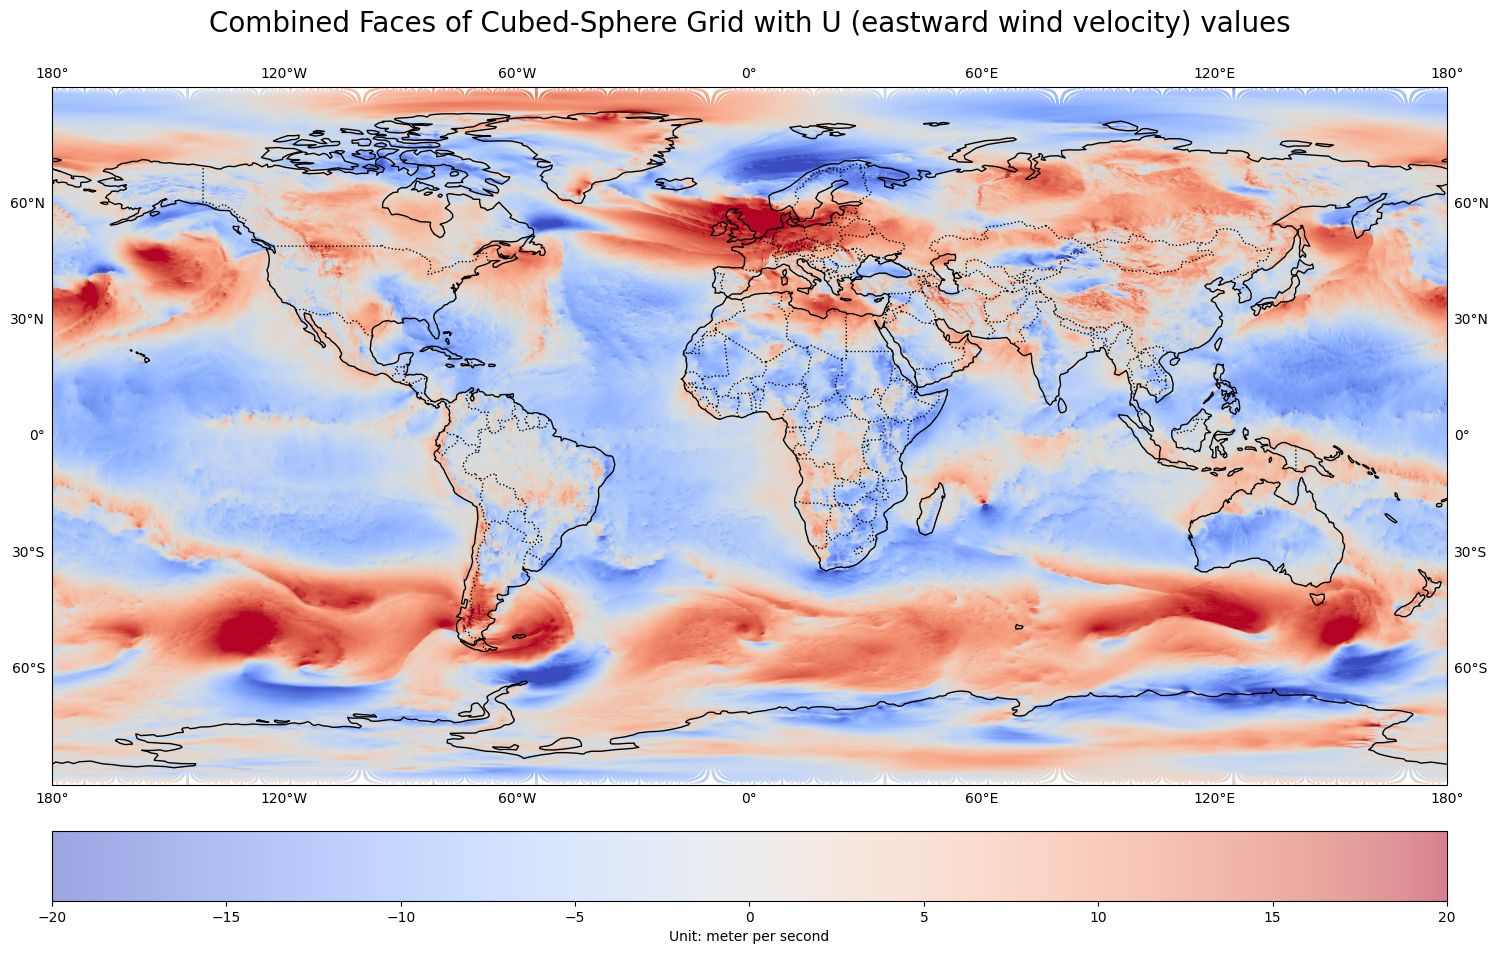

CPU times: user 8min 23s, sys: 1.29 s, total: 8min 24s
Wall time: 8min 25s


In [8]:
%%time
plot_combined_faces_cartopy(latitudes, longitudes, data_faces)